In [12]:
import numpy as np
class NBodySystem:
    def __init__(self, masses, positions, velocities, G=1.0, softening=0.1):
        self.masses = np.asarray(masses, dtype=float).reshape(-1)
        self.pos = np.asarray(positions, dtype=float).reshape(-1, 3).copy()
        self.vel = np.asarray(velocities, dtype=float).reshape(-1, 3).copy()
        self.G = float(G)
        self.softening = float(softening)
        self.N = len(self.masses)

        assert self.pos.shape == (self.N, 3)
        assert self.vel.shape == (self.N, 3)
        self._acc = np.zeros_like(self.pos)
        self.time = 0.0

    def accelerations(self, pos=None):
        if pos is None:
            pos = self.pos
        sep = pos[np.newaxis, :, :] - pos[:, np.newaxis, :]

        dist2 = np.sum(sep * sep, axis=-1) + self.softening ** 2
        inv_dist3 = dist2 ** (-1.5)
        np.fill_diagonal(inv_dist3, 0.0)
        acc = self.G * np.einsum('ijk,j,ij->ik', sep, self.masses, inv_dist3)
        return acc

    def step(self, dt):
        acc = self.accelerations()
        self.vel += acc * (dt / 2.0)
        self.pos += self.vel * dt
        acc = self.accelerations()
        self.vel += acc * (dt / 2.0)
        self.time += dt
        self._acc = acc
        return self.pos, self.vel

    def run(self, dt, n_steps):
        traj = np.empty((n_steps + 1, self.N, 3))
        traj[0] = self.pos
        for i in range(1, n_steps + 1):
            self.step(dt)
            traj[i] = self.pos
        return traj

    def total_energy(self):
        ke = 0.5 * np.sum(self.masses[:, None] * self.vel ** 2)
        sep = self.pos[np.newaxis, :, :] - self.pos[:, np.newaxis, :]
        dist = np.sqrt(np.sum(sep * sep, axis=-1) + self.softening ** 2)
        with np.errstate(divide='ignore'):
            inv_dist = np.where(dist > 0, 1.0 / dist, 0.0)
        pe = -self.G * np.sum(np.triu(self.masses[:, None] * self.masses[None, :] * inv_dist, k=1))
        return ke + pe

In [14]:
"""SOLAR SYSTEM DEMO"""

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection


G = 4 * np.pi ** 2
PLANETS = [
    ("Mercury", 0.387, 1.66e-7, "#8c8c8c", 0.10),
    ("Venus",   0.723, 2.45e-6, "#e0c16c", 1.40),
    ("Earth",   1.000, 3.00e-6, "#4a90d9", 2.60),
    ("Mars",    1.524, 3.23e-7, "#c1440e", 4.00),
    ("Jupiter", 5.203, 9.55e-4, "#d9a066", 0.80),
    ("Saturn",  9.537, 2.86e-4, "#e6c78a", 3.30),
    ("Uranus", 19.191, 4.37e-5, "#8fd9d0", 5.10),
    ("Neptune",30.069, 5.15e-5, "#4166f5", 1.90),
]

SUN_MASS = 1.0
def build_solar_system():
    n_bodies = len(PLANETS) + 1
    masses = np.zeros(n_bodies)
    pos = np.zeros((n_bodies, 3))
    vel = np.zeros((n_bodies, 3))
    colors = ["#ffcc33"]
    names = ["Sun"]
    masses[0] = SUN_MASS
    for i, (name, a, m, color, theta0) in enumerate(PLANETS, start=1):
        masses[i] = m
        pos[i] = [a * np.cos(theta0), a * np.sin(theta0), 0.0]
        v_circ = np.sqrt(G * SUN_MASS / a)
        vel[i] = [-v_circ * np.sin(theta0), v_circ * np.cos(theta0), 0.0]
        colors.append(color)
        names.append(name)
    vel[0] = -np.sum(masses[1:, None] * vel[1:], axis=0) / masses[0]
    return NBodySystem(masses, pos, vel, G=G, softening=0.02), colors, names


def main():
    sim, colors, names = build_solar_system()
    total_years = 165.0
    dt = 0.005
    n_steps = int(total_years / dt)
    n_frames = 300
    steps_per_frame = max(1, n_steps // n_frames)
    trail_len = 400
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="black")
    ax.set_facecolor("black")
    lim = 33
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Inner + outer solar system (1 Neptune orbit ≈ 165 yr)",
                 color="white", fontsize=12)

    scat = ax.scatter(sim.pos[:, 0], sim.pos[:, 1],
                       c=colors, s=[70] + [18] * (sim.N - 1), zorder=5)
    trail_lines = [ax.plot([], [], lw=1, color=colors[i], alpha=0.5)[0]
                   for i in range(sim.N)]
    history = [[] for _ in range(sim.N)]
    time_text = ax.text(0.02, 0.96, "", transform=ax.transAxes,
                         color="white", fontsize=10, va="top")
    def update(frame):
        for _ in range(steps_per_frame):
            sim.step(dt)
        scat.set_offsets(sim.pos[:, :2])
        for i in range(sim.N):
            history[i].append(sim.pos[i, :2].copy())
            if len(history[i]) > trail_len:
                history[i].pop(0)
            pts = np.array(history[i])
            trail_lines[i].set_data(pts[:, 0], pts[:, 1])

        time_text.set_text(f"t = {sim.time:6.1f} yr")
        return [scat, time_text, *trail_lines]

    ani = animation.FuncAnimation(fig, update, frames=n_frames,
                                   interval=40, blit=True)
    out_path = "solar_system.gif"
    ani.save(out_path, writer=animation.PillowWriter(fps=25))
    plt.close(fig)
    print("Saved", out_path)
if __name__ == "__main__":
    main()

Saved solar_system.gif


In [16]:
"""GALAXY COLLISION"""

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.animation as animation

rng = np.random.default_rng(7)
G = 1.0
SOFTENING = 0.6
CENTRAL_MASS = 25.0
STAR_MASS = 0.005


def make_disk(center_pos, center_vel, center_mass, n_stars, r_min, r_max,
              star_mass, thickness=0.3, tilt_deg=0.0):
    radii = rng.uniform(r_min, r_max, n_stars)
    theta = rng.uniform(0, 2 * np.pi, n_stars)

    x = radii * np.cos(theta)
    y = radii * np.sin(theta)
    z = rng.normal(0, thickness, n_stars)
    v_circ = np.sqrt(G * center_mass * radii ** 2 / (radii ** 2 + SOFTENING ** 2) ** 1.5)
    vx = -v_circ * np.sin(theta)
    vy = v_circ * np.cos(theta)
    vz = np.zeros(n_stars)
    pos = np.stack([x, y, z], axis=1)
    vel = np.stack([vx, vy, vz], axis=1)
    t = np.radians(tilt_deg)
    R = np.array([[1, 0, 0],
                  [0, np.cos(t), -np.sin(t)],
                  [0, np.sin(t), np.cos(t)]])
    pos = pos @ R.T
    vel = vel @ R.T

    pos += np.asarray(center_pos)
    vel += np.asarray(center_vel)

    masses = np.full(n_stars, star_mass)
    return masses, pos, vel


def build_colliding_galaxies(n_stars_per_galaxy=180, D=60.0, b=18.0, v_inf=0.8):
    pos_A = np.array([-D / 2, -b / 2, 0.0])
    vel_A = np.array([v_inf / 2, 0.0, 0.0])
    pos_B = np.array([D / 2, b / 2, 0.0])
    vel_B = np.array([-v_inf / 2, 0.0, 0.0])
    mA, pA, vA = make_disk(pos_A, vel_A, CENTRAL_MASS, n_stars_per_galaxy,
                            r_min=3.0, r_max=10.0, star_mass=STAR_MASS, tilt_deg=25)
    mB, pB, vB = make_disk(pos_B, vel_B, CENTRAL_MASS, n_stars_per_galaxy,
                            r_min=3.0, r_max=10.0, star_mass=STAR_MASS, tilt_deg=-15)
    centers_mass = np.array([CENTRAL_MASS, CENTRAL_MASS])
    centers_pos = np.vstack([pos_A, pos_B])
    centers_vel = np.vstack([vel_A, vel_B])
    masses = np.concatenate([centers_mass, mA, mB])
    pos = np.vstack([centers_pos, pA, pB])
    vel = np.vstack([centers_vel, vA, vB])
    sim = NBodySystem(masses, pos, vel, G=G, softening=SOFTENING)
    return sim
def main():
    n_per_galaxy = 180
    sim = build_colliding_galaxies(n_per_galaxy)

    dt = 0.02
    total_time = 80.0
    n_steps = int(total_time / dt)
    n_frames = 260
    steps_per_frame = max(1, n_steps // n_frames)

    center_color = "#ffffff"
    colorsA, colorsB = "#5ec8f8", "#ff8a5c"
    point_colors = np.array(
        [center_color, center_color] +
        [colorsA] * n_per_galaxy +
        [colorsB] * n_per_galaxy
    )
    sizes = np.array([90, 90] + [4] * n_per_galaxy + [4] * n_per_galaxy)

    fig, ax = plt.subplots(figsize=(8, 8), facecolor="black")
    ax.set_facecolor("black")
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Two-galaxy flyby / tidal interaction", color="white", fontsize=12)

    scat = ax.scatter(sim.pos[:, 0], sim.pos[:, 1], c=point_colors, s=sizes,
                       alpha=0.9, linewidths=0)
    time_text = ax.text(0.02, 0.96, "", transform=ax.transAxes,
                         color="white", fontsize=10, va="top")

    def update(frame):
        for _ in range(steps_per_frame):
            sim.step(dt)

        xy = sim.pos[:, :2]
        scat.set_offsets(xy)
        cx, cy = xy.mean(axis=0)
        half_extent = np.max(np.abs(xy - [cx, cy])) * 1.15 + 3
        ax.set_xlim(cx - half_extent, cx + half_extent)
        ax.set_ylim(cy - half_extent, cy + half_extent)

        time_text.set_text(f"t = {sim.time:6.1f}")
        return [scat, time_text]

    ani = animation.FuncAnimation(fig, update, frames=n_frames,
                                   interval=40, blit=False)

    out_path = "galaxy_collision.gif"
    ani.save(out_path, writer=animation.PillowWriter(fps=25))
    plt.close(fig)
    print("Saved", out_path)


if __name__ == "__main__":
    main()

Saved galaxy_collision.gif


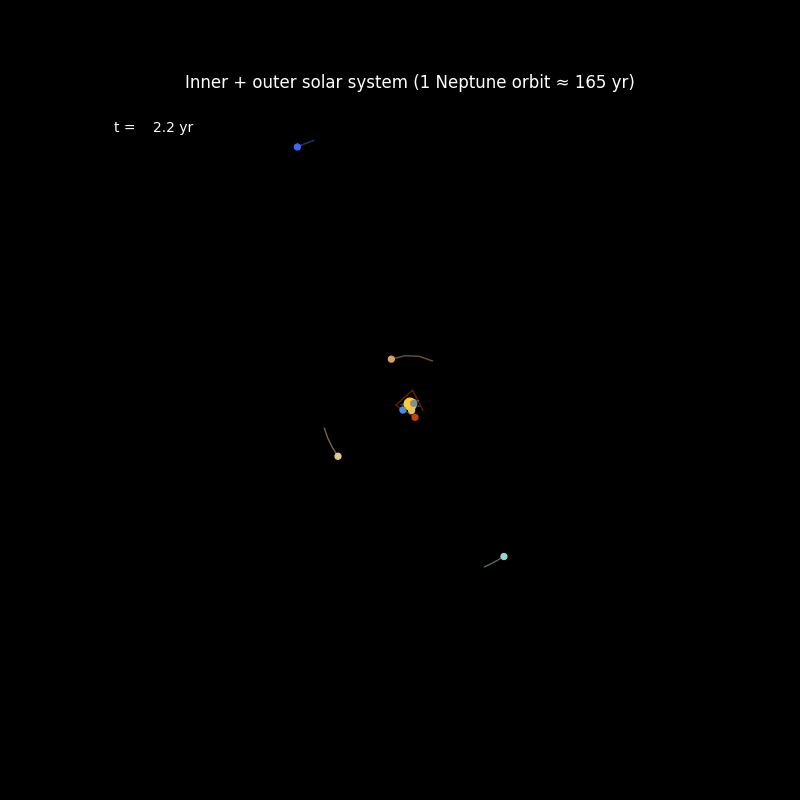

In [15]:
from IPython.display import Image, display
display(Image(filename="solar_system.gif"))

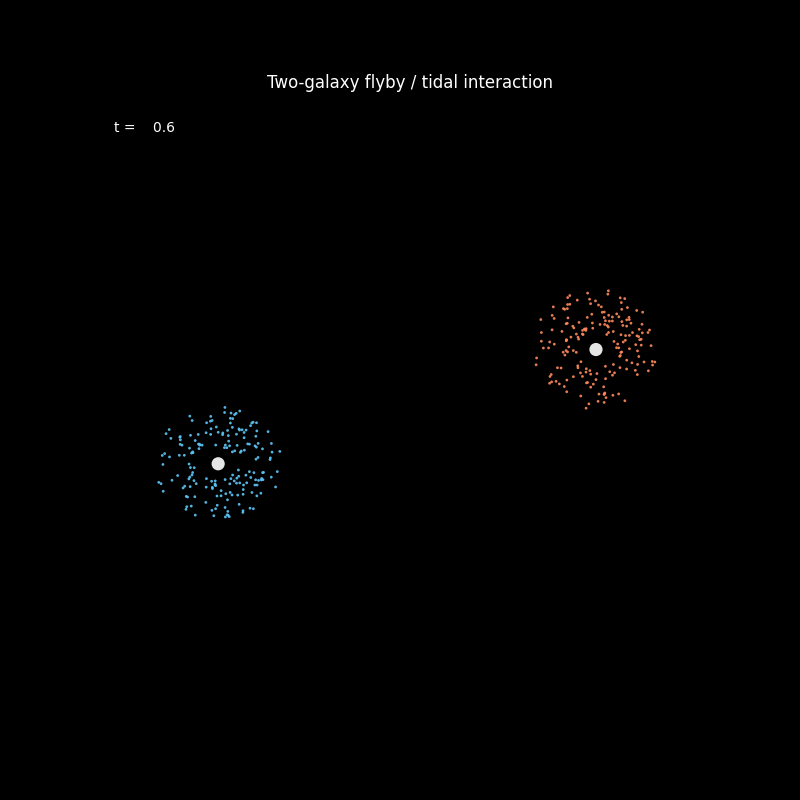

In [17]:
from IPython.display import Image, display
display(Image(filename="galaxy_collision.gif"))